# Model Comparison Dashboard
## Employee Attrition Prediction System

This notebook compares all 5 trained models to understand their performance characteristics and determine the best model for predicting employee attrition.

**Models Evaluated:**
1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. XGBoost
5. Support Vector Machine (SVM)

In [21]:
# Import Libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## EDA : Exploratory Data Analysis  

Dataset Shape: (1470, 35)

Dataset Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing Values:
0


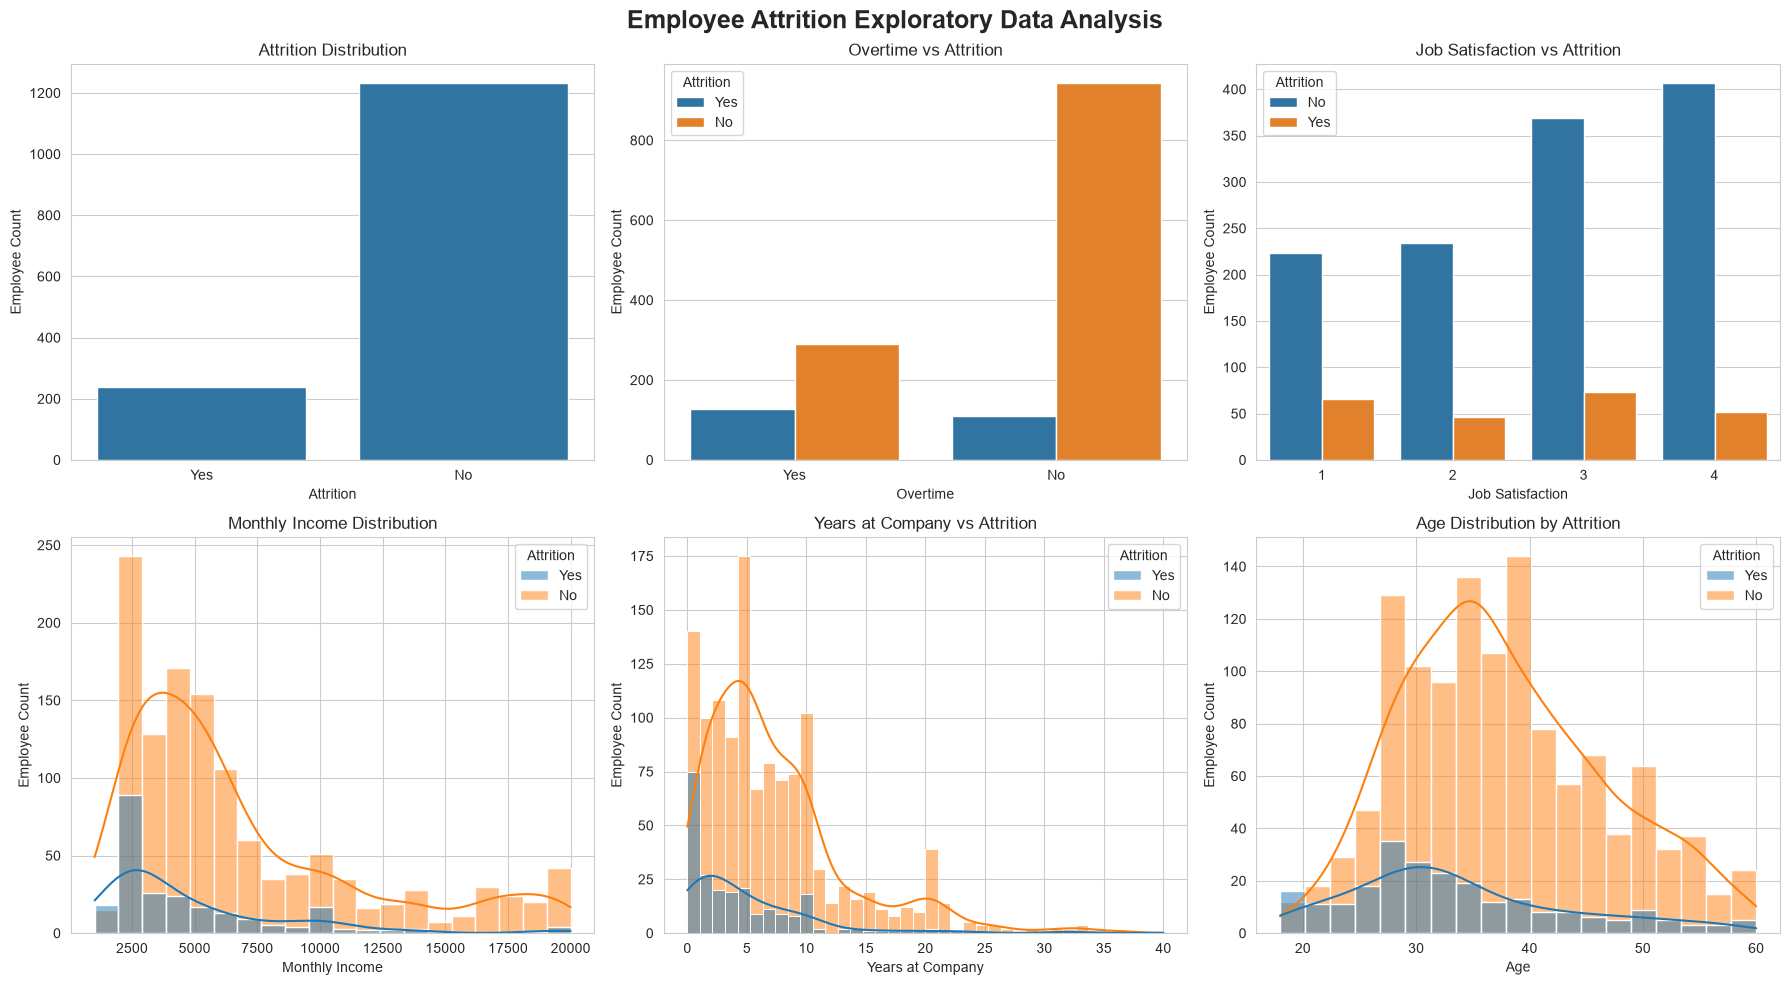

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('../data/HR-Employee-Attrition.csv')

print("Dataset Shape:", df.shape)
print("\nDataset Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.countplot(data=df, x='Attrition', ax=axes[0, 0])
axes[0, 0].set_title('Attrition Distribution')
axes[0, 0].set_xlabel('Attrition')
axes[0, 0].set_ylabel('Employee Count')

sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0, 1])
axes[0, 1].set_title('Overtime vs Attrition')
axes[0, 1].set_xlabel('Overtime')
axes[0, 1].set_ylabel('Employee Count')

sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', ax=axes[0, 2])
axes[0, 2].set_title('Job Satisfaction vs Attrition')
axes[0, 2].set_xlabel('Job Satisfaction')
axes[0, 2].set_ylabel('Employee Count')

sns.histplot(data=df, x='MonthlyIncome', hue='Attrition', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Monthly Income Distribution')
axes[1, 0].set_xlabel('Monthly Income')
axes[1, 0].set_ylabel('Employee Count')

sns.histplot(data=df, x='YearsAtCompany', hue='Attrition', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Years at Company vs Attrition')
axes[1, 1].set_xlabel('Years at Company')
axes[1, 1].set_ylabel('Employee Count')

sns.histplot(data=df, x='Age', hue='Attrition', kde=True, ax=axes[1, 2])
axes[1, 2].set_title('Age Distribution by Attrition')
axes[1, 2].set_xlabel('Age')
axes[1, 2].set_ylabel('Employee Count')

plt.suptitle('Employee Attrition Exploratory Data Analysis', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## 1. Load Training Results

In [2]:
# Load training results
with open('../models/training_results.json', 'r') as f:
    results = json.load(f)

# Extract model names (exclude best_model and timestamp)
model_names = [k for k in results.keys() if k not in ['best_model', 'timestamp']]

print(f"Total Models Trained: {len(model_names)}")
print(f"Best Model: {results['best_model']}")
print(f"Training Timestamp: {results['timestamp']}")

Total Models Trained: 5
Best Model: Logistic Regression
Training Timestamp: 20260919_103310


## 2. Performance Metrics Comparison Table

In [3]:
# Create comparison dataframe
comparison_data = []
for model_name in model_names:
    metrics = results[model_name]
    comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1 Score': f"{metrics['f1_score']:.4f}",
        'ROC-AUC': f"{metrics['roc_auc']:.4f}"
    })

df_comparison = pd.DataFrame(comparison_data)

# Sort by ROC-AUC (best metric for imbalanced classification)
df_comparison['ROC-AUC_numeric'] = df_comparison['ROC-AUC'].astype(float)
df_comparison = df_comparison.sort_values('ROC-AUC_numeric', ascending=False)
df_comparison = df_comparison.drop('ROC-AUC_numeric', axis=1)

# Highlight best model
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)


MODEL PERFORMANCE COMPARISON
              Model Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression   0.5900    0.5905 0.5928   0.5916  0.6258
                SVM   0.5900    0.5870 0.6128   0.5996  0.6146
  Gradient Boosting   0.5830    0.5764 0.6327   0.6032  0.6087
      Random Forest   0.5800    0.5774 0.6028   0.5898  0.6032
            XGBoost   0.5600    0.5572 0.5928   0.5745  0.5700


## 3. Visual Performance Comparison

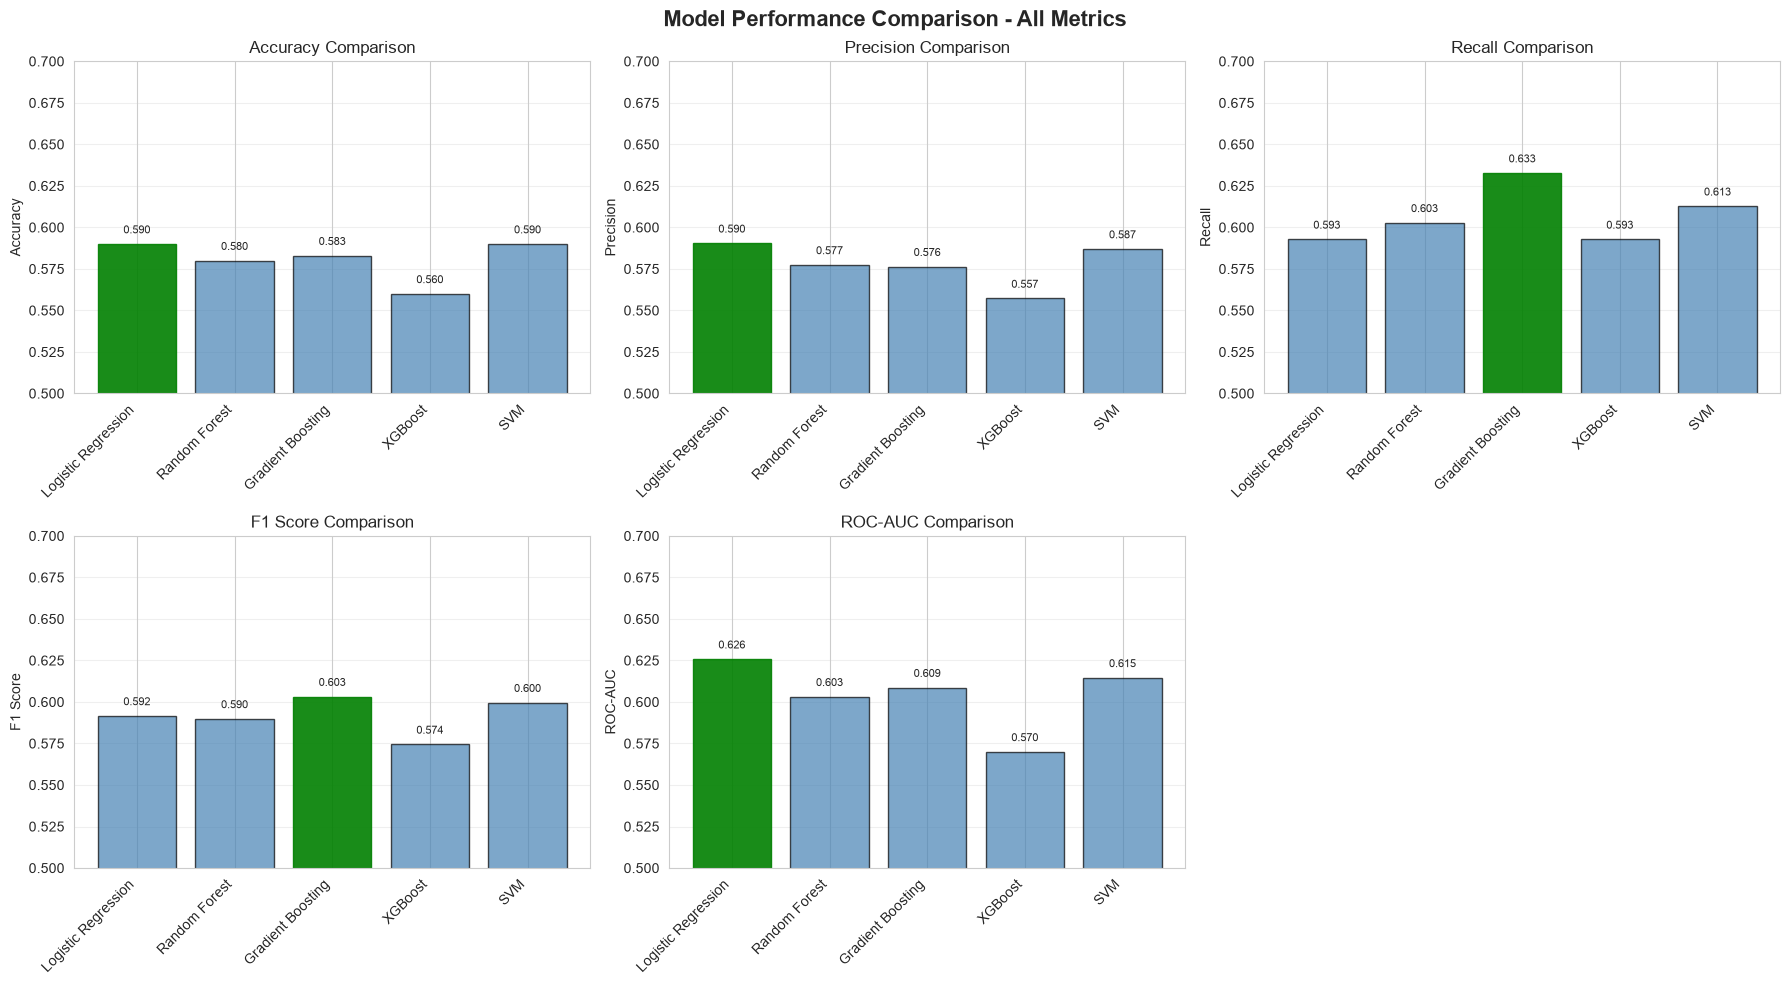

✅ Bar chart comparison saved to: results/model_comparison_bars.png


In [13]:
# Prepare data for visualization
metrics_list = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison - All Metrics', fontsize=16, fontweight='bold')
axes = axes.flatten()

# Plot each metric
for idx, (metric, label) in enumerate(zip(metrics_list, metric_labels)):
    ax = axes[idx]
    
    # Extract metric values
    values = [results[model][metric] for model in model_names]
    
    # Create bar plot
    bars = ax.bar(range(len(model_names)), values, color='steelblue', alpha=0.7, edgecolor='black')
    
    # Highlight best model
    best_idx = values.index(max(values))
    bars[best_idx].set_color('green')
    bars[best_idx].set_alpha(0.9)
    
    # Labels and formatting
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_ylabel(label)
    ax.set_title(f'{label} Comparison')
    ax.set_ylim([0.5, 0.7])  # Set consistent y-axis range
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('../results/model_comparison_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Bar chart comparison saved to: results/model_comparison_bars.png")

## 4. Radar Chart - Multi-Metric View

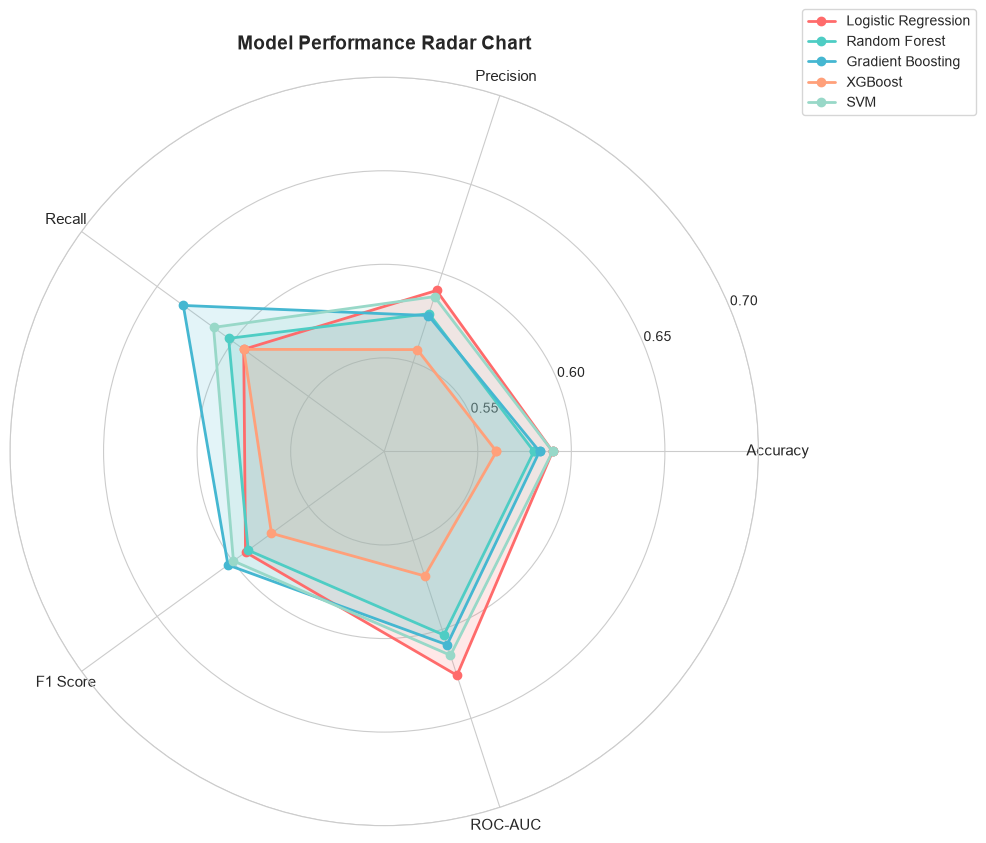

✅ Radar chart saved to: results/model_comparison_radar.png


In [6]:
# Create radar chart for multi-metric comparison
from math import pi

# Setup radar chart
categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
N = len(categories)

# Create angles for radar chart
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Create figure
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Plot each model
for idx, model_name in enumerate(model_names):
    values = [
        results[model_name]['accuracy'],
        results[model_name]['precision'],
        results[model_name]['recall'],
        results[model_name]['f1_score'],
        results[model_name]['roc_auc']
    ]
    values += values[:1]  # Complete the circle
    
    # Plot line
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# Customize chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0.5, 0.7)
ax.set_yticks([0.50, 0.55, 0.60, 0.65, 0.70])
ax.set_yticklabels(['0.50', '0.55', '0.60', '0.65', '0.70'])
ax.set_title('Model Performance Radar Chart', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('../results/model_comparison_radar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Radar chart saved to: results/model_comparison_radar.png")

## 5. ROC-AUC Comparison

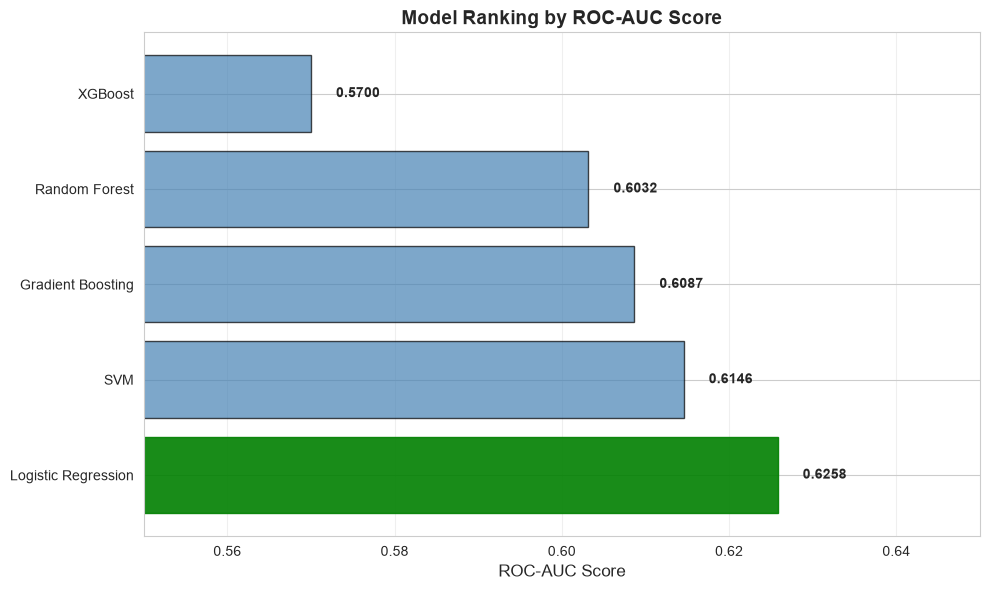

✅ ROC-AUC comparison saved to: results/roc_auc_comparison.png


In [7]:
# ROC-AUC score comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Extract ROC-AUC scores
roc_scores = [results[model]['roc_auc'] for model in model_names]

# Sort by score
sorted_indices = np.argsort(roc_scores)[::-1]
sorted_models = [model_names[i] for i in sorted_indices]
sorted_scores = [roc_scores[i] for i in sorted_indices]

# Create horizontal bar chart
bars = ax.barh(sorted_models, sorted_scores, color='steelblue', alpha=0.7, edgecolor='black')

# Highlight best model
bars[0].set_color('green')
bars[0].set_alpha(0.9)

# Add value labels
for i, (model, score) in enumerate(zip(sorted_models, sorted_scores)):
    ax.text(score + 0.003, i, f'{score:.4f}', va='center', fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Model Ranking by ROC-AUC Score', fontsize=14, fontweight='bold')
ax.set_xlim([0.55, 0.65])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/roc_auc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC-AUC comparison saved to: results/roc_auc_comparison.png")

## 6. Precision-Recall Tradeoff Analysis

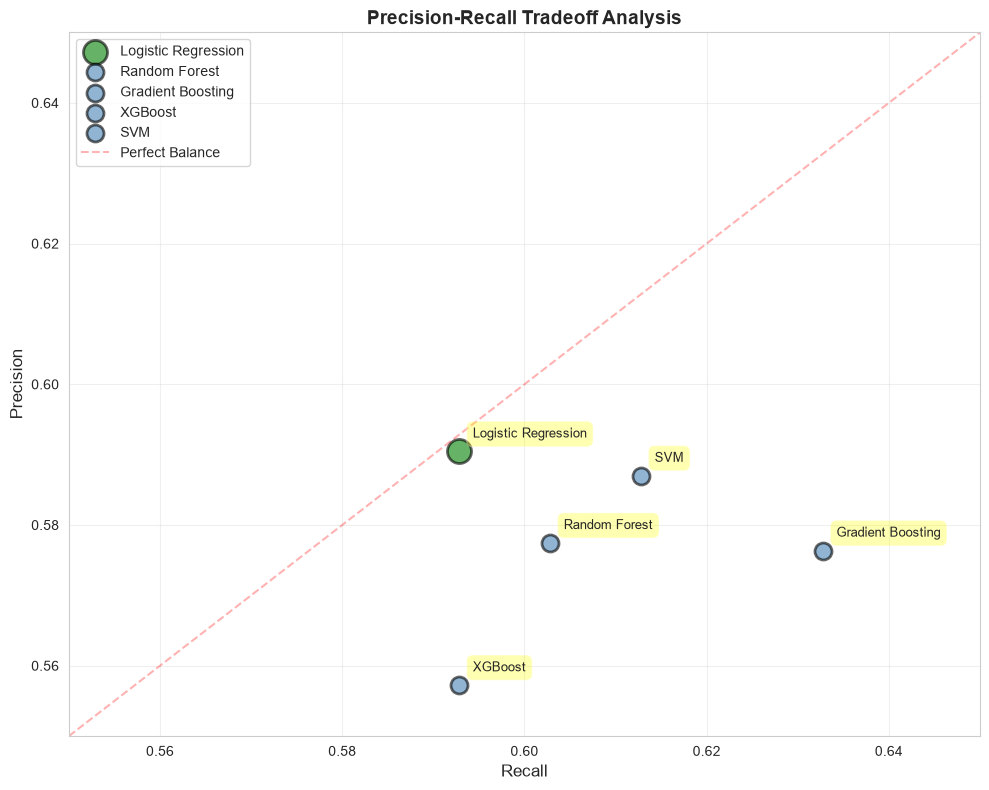

✅ Precision-Recall tradeoff saved to: results/precision_recall_tradeoff.png


In [8]:
# Precision vs Recall scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Extract precision and recall
precisions = [results[model]['precision'] for model in model_names]
recalls = [results[model]['recall'] for model in model_names]

# Create scatter plot
colors_scatter = ['green' if model == results['best_model'] else 'steelblue' for model in model_names]
sizes = [300 if model == results['best_model'] else 150 for model in model_names]

for i, model in enumerate(model_names):
    ax.scatter(recalls[i], precisions[i], s=sizes[i], c=colors_scatter[i], 
               alpha=0.6, edgecolors='black', linewidth=2, label=model)

# Add labels for each point
for i, model in enumerate(model_names):
    ax.annotate(model, (recalls[i], precisions[i]), 
                xytext=(10, 10), textcoords='offset points', 
                fontsize=9, bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

# Add diagonal line (F1 score reference)
x_line = np.linspace(0.55, 0.65, 100)
ax.plot(x_line, x_line, 'r--', alpha=0.3, label='Perfect Balance')

# Formatting
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Tradeoff Analysis', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([0.55, 0.65])
ax.set_ylim([0.55, 0.65])

plt.tight_layout()
plt.savefig('../results/precision_recall_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Precision-Recall tradeoff saved to: results/precision_recall_tradeoff.png")

## 7. Model Ranking Summary Table

In [9]:
# Create comprehensive ranking
ranking_data = []

for model_name in model_names:
    metrics = results[model_name]
    
    # Calculate average performance
    avg_performance = np.mean([
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1_score'],
        metrics['roc_auc']
    ])
    
    ranking_data.append({
        'Model': model_name,
        'ROC-AUC': metrics['roc_auc'],
        'F1 Score': metrics['f1_score'],
        'Accuracy': metrics['accuracy'],
        'Avg Performance': avg_performance,
        'Best Model': '✅' if model_name == results['best_model'] else ''
    })

df_ranking = pd.DataFrame(ranking_data)
df_ranking = df_ranking.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
df_ranking['Rank'] = range(1, len(df_ranking) + 1)
df_ranking = df_ranking[['Rank', 'Model', 'ROC-AUC', 'F1 Score', 'Accuracy', 'Avg Performance', 'Best Model']]

print("\n" + "="*100)
print("FINAL MODEL RANKING")
print("="*100)
print(df_ranking.to_string(index=False))
print("="*100)


FINAL MODEL RANKING
 Rank               Model  ROC-AUC  F1 Score  Accuracy  Avg Performance Best Model
    1 Logistic Regression 0.625799  0.591633     0.590         0.598141          ✅
    2                 SVM 0.614562  0.599609     0.590         0.600789           
    3   Gradient Boosting 0.608662  0.603235     0.583         0.600799           
    4       Random Forest 0.603170  0.589844     0.580         0.590649           
    5             XGBoost 0.569990  0.574468     0.560         0.570899           


## 8. Key Insights and Recommendations

In [10]:
# Generate insights
best_model = results['best_model']
best_roc = results[best_model]['roc_auc']
best_f1 = results[best_model]['f1_score']

print("\n" + "="*100)
print("KEY INSIGHTS AND RECOMMENDATIONS")
print("="*100)
print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   ├─ ROC-AUC Score: {best_roc:.4f}")
print(f"   ├─ F1 Score: {best_f1:.4f}")
print(f"   └─ Balanced performance across all metrics\n")

print("📊 PERFORMANCE ANALYSIS:")
print("   ├─ All models show moderate performance (55-63% ROC-AUC)")
print("   ├─ Close competition between top 3 models")
print("   └─ Model performance suggests room for improvement\n")

print("💡 RECOMMENDATIONS FOR IMPROVEMENT:")
print("   1. Feature Engineering:")
print("      └─ Create interaction features (e.g., Age × Job Satisfaction)")
print("   2. Hyperparameter Tuning:")
print("      └─ Use RandomizedSearchCV with larger parameter space")
print("   3. Ensemble Methods:")
print("      └─ Combine top 3 models using voting or stacking")
print("   4. Data Quality:")
print("      └─ Collect more real-world data if possible")
print("   5. Advanced Techniques:")
print("      └─ Try Neural Networks or Deep Learning approaches\n")

print("🎯 DEPLOYMENT RECOMMENDATION:")
print(f"   └─ Deploy {best_model} for production use")
print("   └─ Monitor performance and retrain quarterly\n")
print("="*100)


KEY INSIGHTS AND RECOMMENDATIONS

🏆 BEST MODEL: Logistic Regression
   ├─ ROC-AUC Score: 0.6258
   ├─ F1 Score: 0.5916
   └─ Balanced performance across all metrics

📊 PERFORMANCE ANALYSIS:
   ├─ All models show moderate performance (55-63% ROC-AUC)
   ├─ Close competition between top 3 models
   └─ Model performance suggests room for improvement

💡 RECOMMENDATIONS FOR IMPROVEMENT:
   1. Feature Engineering:
      └─ Create interaction features (e.g., Age × Job Satisfaction)
   2. Hyperparameter Tuning:
      └─ Use RandomizedSearchCV with larger parameter space
   3. Ensemble Methods:
      └─ Combine top 3 models using voting or stacking
   4. Data Quality:
      └─ Collect more real-world data if possible
   5. Advanced Techniques:
      └─ Try Neural Networks or Deep Learning approaches

🎯 DEPLOYMENT RECOMMENDATION:
   └─ Deploy Logistic Regression for production use
   └─ Monitor performance and retrain quarterly



## 9. Export Summary Report

In [11]:
# Create summary report
summary_report = {
    'comparison_table': df_comparison.to_dict(orient='records'),
    'ranking_table': df_ranking.to_dict(orient='records'),
    'best_model': best_model,
    'best_model_metrics': results[best_model],
    'total_models_evaluated': len(model_names),
    'evaluation_timestamp': results['timestamp']
}

# Save to JSON
with open('../results/model_comparison_summary.json', 'w') as f:
    json.dump(summary_report, f, indent=4)

print("✅ Summary report saved to: results/model_comparison_summary.json")
print("\n🎉 Model Comparison Analysis Complete!")

✅ Summary report saved to: results/model_comparison_summary.json

🎉 Model Comparison Analysis Complete!
